In [103]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import cv2
import re

In [104]:
folder_list = os.listdir('DATA/DATA/train/')

In [105]:
X_train = []
y_train = []
for i in range(0, len(folder_list), 2):
    try:
        image_path = f'DATA/DATA/train/{folder_list[i]}' 
        xml_path = f'DATA/DATA/train/{folder_list[i + 1]}'
        image = mpimg.imread(image_path)
        x_shape = image.shape[1]
        y_shape = image.shape[0]
        xml = open(xml_path, 'r', encoding='utf-8')
        text = xml.read()
        xmin, ymin, xmax, ymax = re.findall(r'<(?:xmin|ymin|xmax|ymax)>(\d+)</(?:xmin|ymin|xmax|ymax)>', text)
        xmin = int(xmin)
        ymin = int(ymin)
        xmax = int(xmax)
        ymax = int(ymax)
        image = cv2.resize(image, (200, 200))
        xmin = int(xmin * 200 / x_shape)
        ymin = int(ymin * 200 / y_shape)
        xmax = int(xmax * 200 / x_shape)
        ymax = int(ymax * 200 / y_shape)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        image = image.reshape(200, 200, 1)
        image = image / 255
        X_train.append(image)
        y_train.append([xmin, ymin, xmax, ymax])
    except:
        continue
X_train = np.array(X_train)
y_train = np.array(y_train)


In [106]:
folder_list_test = os.listdir('DATA/DATA/test/')

In [107]:
X_test = []
y_test = []
for i in range(0, len(folder_list_test), 2):
    try:
        image_path = f'DATA/DATA/test/{folder_list_test[i]}' 
        xml_path = f'DATA/DATA/test/{folder_list_test[i + 1]}'
        image = mpimg.imread(image_path)
        x_shape = image.shape[1]
        y_shape = image.shape[0]
        xml = open(xml_path, 'r', encoding='utf-8')
        text = xml.read()
        xmin, ymin, xmax, ymax = re.findall(r'<(?:xmin|ymin|xmax|ymax)>(\d+)</(?:xmin|ymin|xmax|ymax)>', text)
        xmin = int(xmin)
        ymin = int(ymin)
        xmax = int(xmax)
        ymax = int(ymax)
        image = cv2.resize(image, (200, 200))
        xmin = int(xmin * 200 / x_shape)
        ymin = int(ymin * 200 / y_shape)
        xmax = int(xmax * 200 / x_shape)
        ymax = int(ymax * 200 / y_shape)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        image = image.reshape(200, 200, 1)
        image = image / 255
        X_test.append(image)
        y_test.append([xmin, ymin, xmax, ymax])
    except:
        continue
X_test = np.array(X_test)
y_test = np.array(y_test)


In [108]:
X_train.shape

(228, 200, 200, 1)

In [109]:
y_train.shape

(228, 4)

In [110]:
X_test.shape

(49, 200, 200, 1)

In [111]:
y_test.shape

(49, 4)

In [113]:
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout, Dense
from keras.optimizers import Adam

In [117]:
model = Sequential()

model.add(Conv2D(filters=64, kernel_size=(5, 5), activation='relu', input_shape=(200, 200, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(units=120, activation='relu'))
model.add(Dense(units=60, activation='relu'))
model.add(Dense(units=30, activation='relu'))
model.add(Dense(units=4, activation='linear'))

C:\Users\ASUS\Desktop\ML_18-35_Hrach\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [118]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='mae')

In [119]:
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 310ms/step - loss: 91.8830 - val_loss: 36.9866
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 282ms/step - loss: 43.0288 - val_loss: 26.9618
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 286ms/step - loss: 34.2116 - val_loss: 22.5509
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 286ms/step - loss: 28.5562 - val_loss: 16.6346
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 281ms/step - loss: 20.1777 - val_loss: 18.9684
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 279ms/step - loss: 20.2658 - val_loss: 17.2974
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 281ms/step - loss: 19.9646 - val_loss: 19.2325
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 283ms/step - loss: 18.6033 - val_loss: 15.6909
Epoch 9/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 288ms/step - loss: 17.1028 - val_loss: 14.9868
Epoch 10/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 284ms/step - loss: 16.5113 - val_loss: 15.2416
Epoch 11/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 293ms/step - loss: 16.6482 - val_loss: 15.1615
Epoch 12/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 280ms/step -

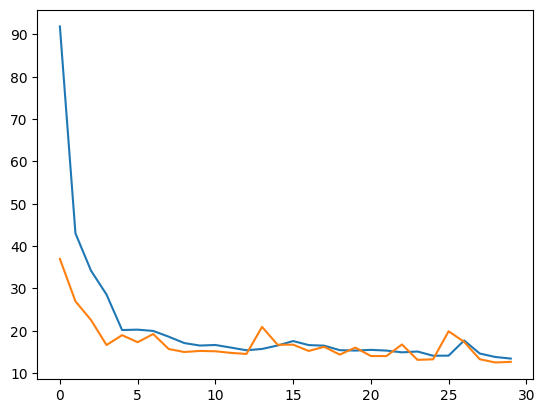

In [120]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

In [134]:
test_image = mpimg.imread('dodge.jpg')

In [135]:
test_image = cv2.resize(test_image, (200, 200))
test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2GRAY)
test_image = test_image / 255
test_image = test_image.reshape(1, 200, 200, 1)

In [136]:
xmin, ymin, xmax, ymax = model.predict(test_image)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


In [137]:
xmin = int(xmin)
ymin = int(ymin)
xmax = int(xmax)
ymax = int(ymax)

In [138]:
test_image = test_image.reshape(200, 200, 1)
test_image_copy = test_image.copy()
cv2.rectangle(test_image_copy, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)

array([[[0.83137255],
        [0.83137255],
        [0.83137255],
        ...,
        [0.69411765],
        [0.69411765],
        [0.69411765]],

       [[0.83529412],
        [0.83529412],
        [0.83529412],
        ...,
        [0.69803922],
        [0.69411765],
        [0.69411765]],

       [[0.83921569],
        [0.83529412],
        [0.83529412],
        ...,
        [0.70196078],
        [0.70588235],
        [0.70588235]],

       ...,

       [[0.41176471],
        [0.38431373],
        [0.37647059],
        ...,
        [0.19215686],
        [0.19607843],
        [0.19215686]],

       [[0.37254902],
        [0.38823529],
        [0.38823529],
        ...,
        [0.18823529],
        [0.18823529],
        [0.18431373]],

       [[0.37647059],
        [0.38823529],
        [0.4       ],
        ...,
        [0.17647059],
        [0.18039216],
        [0.17647059]]], shape=(200, 200, 1))

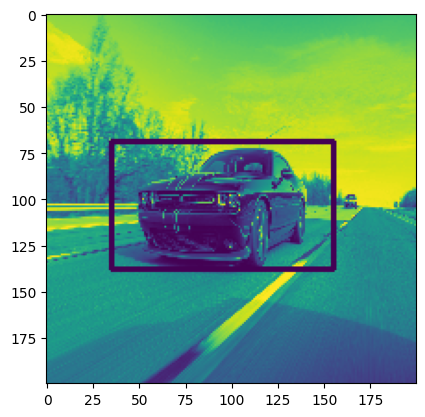

In [139]:
plt.imshow(test_image_copy)